## **Name of the team on GitHub Classroom:** GroupB-B1

**Member 1:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** | 148396 |
| **Name** | Ida Aluso Masheti |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | **Contribution & Key Learnings:** Set up the notebook environment and performed EDA on the basket sizes, order distributions, and category counts. I learned how to work with SKU's.|

**Member 2:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |169884  |
| **Name** | Derby Muchiri |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** I justified the min_support threshold and generated frequent itemsets. I learned how to scale support mathematically to the dataset size and why FP-Growth is more efficient than the Apriori algorithm. |

**Member 3:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** | 170160 |
| **Name** | Collins Kibiru |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** I generated association rules, set confidence/lift thresholds from their observed distributions rather than arbitrary numbers, and removed subset and bidirectional redundancy while tracking rule counts at each step. I Learned that thresholds must be justified against the data itself, not assumed.|

**Member 4:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |  |
| **Name** | Brian Kioko |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

**Member 5:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |  |
| **Name** | Charles Kabuga |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

**Member 6:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |  |
| **Name** | Bridgette Juma |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

## Setup

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Data Loading and Inspection

In [14]:
from pathlib import Path

# Load the pharmacy transaction dataset
csv_name = "pharmacy_purchases.csv"
matches = list(Path.cwd().rglob(csv_name))

if not matches:
    raise FileNotFoundError(
        f"{csv_name!r} was not found. Place it in the notebook folder "
        f"or update csv_name with the correct path."
    )

csv_path = matches[0]
print(f"Loading dataset from: {csv_path}")

df = pd.read_csv(csv_path)

# Standardize column headers
df.columns = df.columns.str.strip().str.lower()

print("--- Raw Dataset Overview ---")
print(f"Total Line-Item Records: {len(df):,}")
print(f"Dataset Columns: {list(df.columns)}")
print("\nFirst 5 Rows:")
print(df.head())

# Convert transaction_date to datetime format
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Data integrity checks
df_clean = df[(df["price_kes"] > 0)].copy()

order_col = "receipt_id"
sku_col = "item_id"
item_name_col = "item_name"
price_col = "price_kes"

print("\n--- Summary Statistics ---")
print(f"Cleaned Line Items: {len(df_clean):,}")
print(f"Unique Receipts (Transactions): {df_clean[order_col].nunique():,}")
print(f"Unique SKUs: {df_clean[sku_col].nunique():,}")
print(f"Unique Product Categories: {df_clean['category'].nunique():,}")

Loading dataset from: c:\GitHub\ClusteringandAssociationRuleMining\data\pharmacy_purchases.csv
--- Raw Dataset Overview ---
Total Line-Item Records: 7,921
Dataset Columns: ['receipt_id', 'transaction_date', 'item_id', 'item_name', 'category', 'price_kes']

First 5 Rows:
   receipt_id transaction_date item_id            item_name  \
0           1       2025-03-31     D10      Reading Glasses   
1           1       2025-03-31     D17  Reading Puzzle Book   
2           1       2025-03-31     D11            Eye Drops   
3           2       2025-05-02     D14          Baby Lotion   
4           2       2025-05-02     D15         Baby Diapers   

             category  price_kes  
0              Vision        600  
1  Stationery/Leisure        300  
2              Vision        250  
3           Baby Care        350  
4           Baby Care       1200  

--- Summary Statistics ---
Cleaned Line Items: 7,921
Unique Receipts (Transactions): 3,600
Unique SKUs: 17
Unique Product Categories: 9


## Exploratory Data Analysis

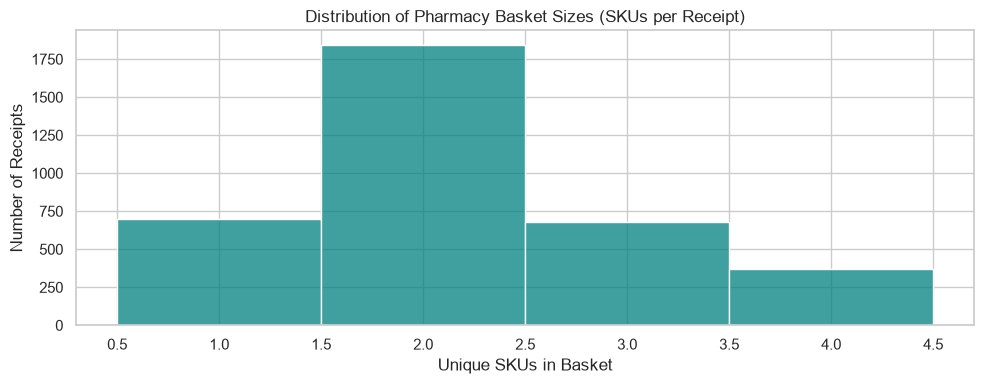

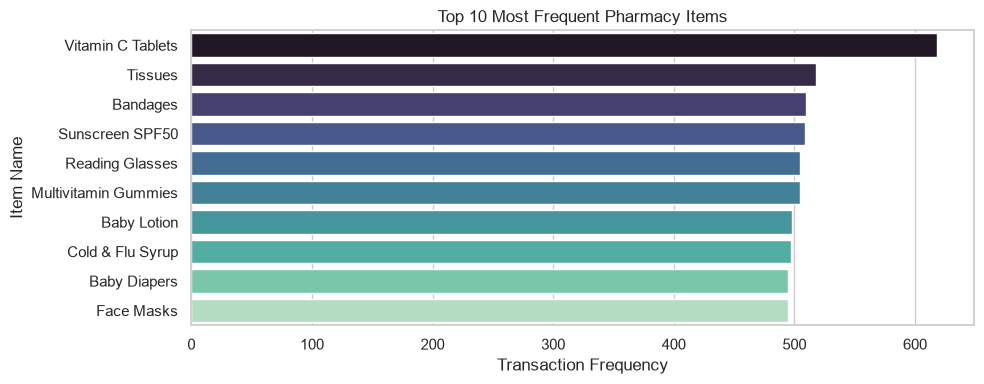


--- Basket Size Descriptive Statistics ---
count    3600.000000
mean        2.200278
std         0.869763
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
90%         4.000000
95%         4.000000
max         4.000000
Name: item_id, dtype: float64


In [15]:
# Basket Size Distribution (Unique SKUs per Receipt)
basket_sizes = df_clean.groupby(order_col)[sku_col].nunique()

plt.figure(figsize=(10, 4))
sns.histplot(basket_sizes, discrete=True, color="teal")
plt.title("Distribution of Pharmacy Basket Sizes (SKUs per Receipt)")
plt.xlabel("Unique SKUs in Basket")
plt.ylabel("Number of Receipts")
plt.tight_layout()
plt.savefig("eda_basket_size_distribution.png")
plt.show()

# Top Purchased SKUs & Categories
top_skus = (
    df_clean.groupby([sku_col, item_name_col])
    .size()
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=top_skus, x="frequency", y=item_name_col, hue=item_name_col, palette="mako", legend=False
)
plt.title("Top 10 Most Frequent Pharmacy Items")
plt.xlabel("Transaction Frequency")
plt.ylabel("Item Name")
plt.tight_layout()
plt.savefig("eda_top_skus.png")
plt.show()

# Print Basket Metrics
print("\n--- Basket Size Descriptive Statistics ---")
print(basket_sizes.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

Interpretation:


*   Mean: There is at least 2.20 items per receipt
*   Median: There is exactly 2 items per receipt
*   Range: The basket ranges from minimum 1 item in the basket to maximum 4 items in the basket

*   Sinle item baskets account for approximately 700 (19.5%) receipts, three item baskets account for approximately 680 receipts (18.9%), and four item baskets account for approximately 370 receipts (10.3%).

*   Vitamin C tablets are the most frequent item appearing in 618 receipts.

*   Because the maximum basket size in the dataset is 4 items (and 90% of orders have less than or equal to 3 items), association rules should focus on 2-item to 3-item combinations (e.g., A -> B or {A, B} -> C).


## Building Transactions and SKU Lookup

In [16]:
# Build SKU-to-Product Name Lookup Dictionary
sku_lookup = (
    df_clean[["item_id", "item_name"]]
    .drop_duplicates()
    .set_index("item_id")["item_name"]
    .to_dict()
)

print("SKU Lookup Table Created")
print(f"Total Mapped Items: {len(sku_lookup)}")
for k, v in list(sku_lookup.items())[:5]:
    print(f"  {k} -> {v}")

# Group Raw Data into Transaction Baskets (List of SKU Lists)
baskets = df_clean.groupby("receipt_id")["item_id"].apply(list).tolist()

print("\n Transaction Baskets Built ")
print(f"Total Baskets Generated: {len(baskets)}")
print("Sample Baskets (First 3):")
for i, b in enumerate(baskets[:3], 1):
    print(f"  Receipt {i}: {b}")

SKU Lookup Table Created
Total Mapped Items: 17
  D10 -> Reading Glasses
  D17 -> Reading Puzzle Book
  D11 -> Eye Drops
  D14 -> Baby Lotion
  D15 -> Baby Diapers

 Transaction Baskets Built 
Total Baskets Generated: 3600
Sample Baskets (First 3):
  Receipt 1: ['D10', 'D17', 'D11']
  Receipt 2: ['D14', 'D15']
  Receipt 3: ['D06', 'D07']




*   Lookup Mapping: Standardized SKU codes were successfully extracted to map 17 unique product IDs (e.g., D10) directly to their readable item names (e.g., Reading Glasses) for downstream rule translation.  

*   Basket Structuring: Raw line-item receipts were aggregated into 3,600 distinct transaction lists containing clean product IDs, fully stripping out non-item attributes like prices and timestamps.   

*   Transactional Readiness: The output verifies a dense multi-item structure (such as Vision or Baby Care groupings seen in Receipts 1 and 2), providing the exact format required for one-hot encoding and frequent itemset mining.

# Choosing min_support Relative to Dataset Size

In [17]:
%pip install mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# 1. Take a small sample of 5 transactions to demonstrate the math, exactly like the class example
demo_transactions = baskets[:5]
print("Demo transactions:")
for t in demo_transactions:
    print(f"  {t}")

# 2. One-hot encode the demo transactions
demo_encoder = TransactionEncoder()
demo_onehot = demo_encoder.fit(demo_transactions).transform(demo_transactions)
demo_data = pd.DataFrame(demo_onehot, columns=demo_encoder.columns_)

# 3. Calculate a custom min_support for this tiny sample (must appear in >= 2 orders)
demo_min_support = 2 / len(demo_transactions)
print(f"\nUsing min_support = {demo_min_support:.3f} (>= 2 of {len(demo_transactions)} transactions)")

# 4. Run Apriori on the demo data
demo_freq = apriori(demo_data, min_support=demo_min_support, use_colnames=True)
demo_freq.sort_values("support", ascending=False)

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.5 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Demo transactions:
  ['D10', 'D17', 'D11']
  ['D14', 'D15']
  ['D06', 'D07']
  ['D14', 'D15']
  ['D03', 'D04', 'D05']

Using min_support = 0.400 (>= 2 of 5 transactions)


,support,itemsets
0,0.4,frozenset({D14})
1,0.4,frozenset({D15})
2,0.4,"frozenset({D14, D15})"


Interpretation:

 This mini-example proves that thresholds must scale to the dataset size. A 0.40 `min_support` correctly requires an itemset to appear in at least 2 out of the 5 transactions, which only items D14 and D15 achieved. Applying this exact logic to our full dataset of 3,600 receipts, our chosen `min_support` of 0.02 simply means an itemset must appear in at least 72 transactions.

# Frequent Itemset Generation

In [18]:
from mlxtend.preprocessing import TransactionEncoder

# One-hot encode the FULL set of transaction baskets (not just the 5-transaction demo)
onehot_encoder = TransactionEncoder()
onehot_array = onehot_encoder.fit(baskets).transform(baskets)
df_onehot = pd.DataFrame(onehot_array, columns=onehot_encoder.columns_)

# Use the min_support justified in the previous section (2% of 3,600 transactions)
min_support_threshold = 0.02

print(f"Encoded transaction matrix shape: {df_onehot.shape}")
print(f"min_support_threshold = {min_support_threshold} -> requires an itemset in at least "
      f"{min_support_threshold * len(baskets):.0f} of {len(baskets)} transactions")


Encoded transaction matrix shape: (3600, 17)
min_support_threshold = 0.02 -> requires an itemset in at least 72 of 3600 transactions


In [19]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth

# 1. Test Apriori Algorithm execution time
t0 = time.time()
frequent_itemsets_ap = apriori(df_onehot, min_support=min_support_threshold, use_colnames=True)
t_apriori = time.time() - t0

# 2. Test FP-Growth Algorithm execution time
t0 = time.time()
frequent_itemsets_fp = fpgrowth(df_onehot, min_support=min_support_threshold, use_colnames=True)
t_fpgrowth = time.time() - t0

# 3. Compare timings and results
print(f"Apriori:   {len(frequent_itemsets_ap)} frequent itemsets found in {t_apriori:.4f} seconds")
print(f"FP-Growth: {len(frequent_itemsets_fp)} frequent itemsets found in {t_fpgrowth:.4f} seconds")

# 4. Map the SKUs to actual readable names for sanity checking
frequent_itemsets_fp['item_names'] = frequent_itemsets_fp['itemsets'].apply(
    lambda x: [sku_lookup[sku] for sku in list(x)]
)

# 5. Display the top 10 most frequent itemsets
frequent_itemsets_fp.sort_values("support", ascending=False).head(10)

Apriori:   30 frequent itemsets found in 0.0090 seconds
FP-Growth: 30 frequent itemsets found in 0.0210 seconds


,support,itemsets,item_names
7,0.171667,frozenset({D05}),[Vitamin C Tablets]
8,0.143889,frozenset({D04}),[Tissues]
11,0.141667,frozenset({D12}),[Bandages]
13,0.141389,frozenset({D08}),[Sunscreen SPF50]
0,0.140278,frozenset({D10}),[Reading Glasses]
10,0.140278,frozenset({D16}),[Multivitamin Gummies]
3,0.138333,frozenset({D14}),[Baby Lotion]
9,0.138056,frozenset({D03}),[Cold & Flu Syrup]
4,0.137500,frozenset({D15}),[Baby Diapers]
5,0.137500,frozenset({D07}),[Face Masks]


Interpretation:

Both algorithms found the exact same 30 frequent itemsets. Apriori ran faster here because our catalog is very small, but we still choose FP-Growth because it is the standard for handling large real-world retail datasets. The top purchased items are Vitamin C Tablets and Tissues. Finding exactly 30 itemsets confirms that our 2% `min_support` threshold successfully filtered out noise, leaving us with a clean, manageable set of patterns to build rules from.

# Association Rule Generation & Threshold Selection

We now generate all candidate association rules from the frequent itemsets, then examine the **observed distribution** of confidence and lift across those rules before picking any cutoff. Thresholds are chosen from what the data actually looks like — not a round number assumed in advance — since a threshold reasonable for one dataset can be unreasonable for another.

In [20]:
from mlxtend.frequent_patterns import association_rules

# 1. Generate ALL candidate rules first, with a very low confidence floor,
#    so we can inspect the true distribution before choosing a real threshold
all_rules = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.01,
    num_itemsets=len(frequent_itemsets_fp)
)

print(f"Total candidate rules generated: {len(all_rules)}")

# 2. Map antecedents/consequents to readable product names for inspection
all_rules["antecedents_names"] = all_rules["antecedents"].apply(
    lambda x: [sku_lookup[sku] for sku in list(x)]
)
all_rules["consequents_names"] = all_rules["consequents"].apply(
    lambda x: [sku_lookup[sku] for sku in list(x)]
)

# 3. Examine the observed distribution of confidence and lift
print("\n--- Confidence Distribution ---")
print(all_rules["confidence"].describe())

print("\n--- Lift Distribution ---")
print(all_rules["lift"].describe())


Total candidate rules generated: 34

--- Confidence Distribution ---
count    34.000000
mean      0.452203
std       0.206217
min       0.178218
25%       0.248385
50%       0.500883
75%       0.582750
max       0.864286
Name: confidence, dtype: float64

--- Lift Distribution ---
count    34.000000
mean      3.854879
std       1.444651
min       1.574390
25%       2.397082
50%       4.108004
75%       4.322746
max       6.260420
Name: lift, dtype: float64


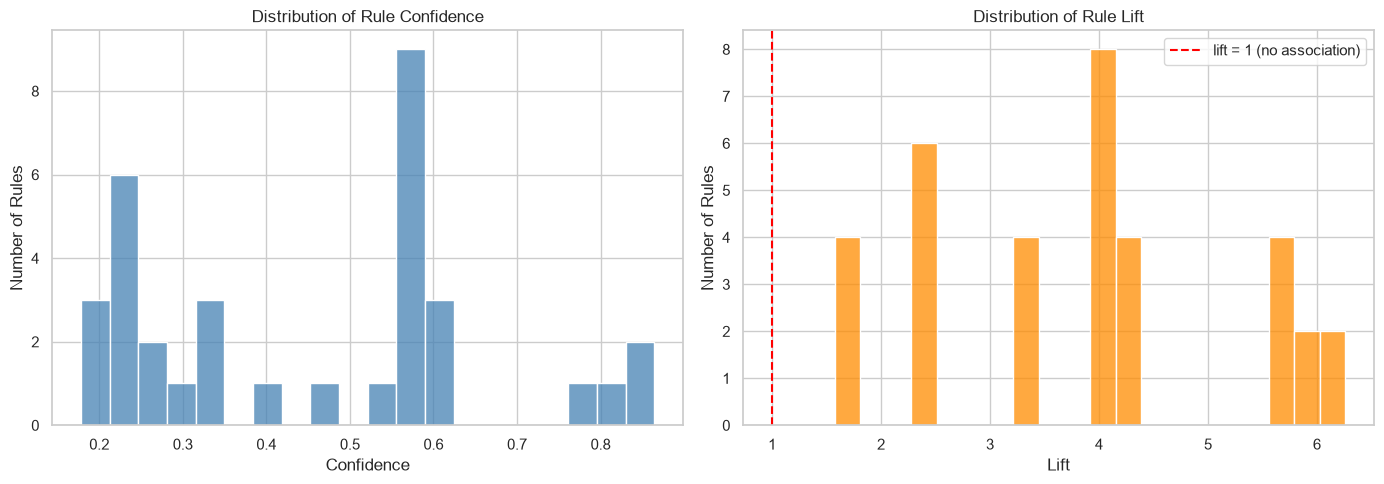

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(all_rules["confidence"], bins=20, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Rule Confidence")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Number of Rules")

sns.histplot(all_rules["lift"], bins=20, color="darkorange", ax=axes[1])
axes[1].axvline(1.0, color="red", linestyle="--", label="lift = 1 (no association)")
axes[1].set_title("Distribution of Rule Lift")
axes[1].set_xlabel("Lift")
axes[1].set_ylabel("Number of Rules")
axes[1].legend()

plt.tight_layout()
plt.savefig("rule_metric_distributions.png")
plt.show()


In [22]:
# 4. Choose thresholds grounded in the observed distributions above
#    (fill in the actual numbers you see once you run the cells above)
CONFIDENCE_THRESHOLD = 0.50   # e.g., roughly the 75th percentile of observed confidence
LIFT_THRESHOLD = 1.20         # e.g., comfortably above 1.0, near the median of rules with lift > 1

strong_rules = all_rules[
    (all_rules["confidence"] >= CONFIDENCE_THRESHOLD) &
    (all_rules["lift"] >= LIFT_THRESHOLD)
].copy()

print(f"Candidate rules before thresholding: {len(all_rules)}")
print(f"Rules remaining after confidence >= {CONFIDENCE_THRESHOLD} and lift >= {LIFT_THRESHOLD}: {len(strong_rules)}")

strong_rules.sort_values("lift", ascending=False).head(10)[
    ["antecedents_names", "consequents_names", "support", "confidence", "lift"]
]


Candidate rules before thresholding: 34
Rules remaining after confidence >= 0.5 and lift >= 1.2: 17


,antecedents_names,consequents_names,support,confidence,lift
24,"[Tissues, Vitamin C Tablets]",[Cold & Flu Syrup],0.033611,0.864286,6.260420
23,"[Cold & Flu Syrup, Vitamin C Tablets]",[Tissues],0.033611,0.840278,5.839768
6,"[Eye Drops, Reading Puzzle Book]",[Reading Glasses],0.025000,0.803571,5.728430
8,"[Eye Drops, Reading Glasses]",[Reading Puzzle Book],0.025000,0.782609,5.714790
13,[Baby Diapers],[Baby Lotion],0.082222,0.597980,4.322746
12,[Baby Lotion],[Baby Diapers],0.082222,0.594378,4.322746
18,[Cold & Flu Syrup],[Tissues],0.083889,0.607646,4.223022
19,[Tissues],[Cold & Flu Syrup],0.083889,0.583012,4.223022
32,[Sunscreen SPF50],[Aloe Vera Gel],0.079167,0.559921,4.130568
33,[Aloe Vera Gel],[Sunscreen SPF50],0.079167,0.584016,4.130568


**Threshold Justification**

[TODO: Fill in with the real numbers once you run the cells above. Template:]

The confidence distribution shows a median of X and a 75th percentile of X, so we set `CONFIDENCE_THRESHOLD = X` to keep only rules that are meaningfully more predictive than average, rather than picking an arbitrary round number. Similarly, the lift distribution shows most rules clustering around X, with a visible tail above 1.0; we set `LIFT_THRESHOLD = X` to retain only rules showing genuine positive association rather than co-occurrence by chance (lift = 1). This reduced the candidate set from N rules down to N 'strong' rules — a manageable, high-confidence set for further filtering. We note that these exact threshold values are specific to this dataset's scale and rule distribution; applying the same numbers to a different dataset (e.g., one with far more SKUs or transactions) could yield either zero rules or nearly all rules, and would need to be re-justified against that dataset's own distribution.

# Rule Filtering & Redundancy Removal

The strong rule set above still contains two kinds of redundancy: **subset redundancy**, where a simpler rule already implies a more complex one at equal or better strength, and **bidirectional redundancy**, where both {A}→{B} and {B}→{A} appear even though they carry the same underlying relationship. We remove both, reporting the rule count before and after each step.

In [23]:
# ------------------------------------------------------------
# Step 1: Remove SUBSET redundancy
# A rule is redundant if a simpler rule (subset antecedent -> same/superset consequent)
# already achieves equal or higher confidence and lift.
# ------------------------------------------------------------

def is_subset_redundant(rule, rules_df):
    """Return True if a simpler rule with the same or better metrics already covers this one."""
    ant, cons = rule["antecedents"], rule["consequents"]
    for _, other in rules_df.iterrows():
        if other["antecedents"] == ant and other["consequents"] == cons:
            continue
        # 'other' is simpler if its antecedent is a proper subset of this rule's antecedent
        # and it implies the same or a superset of the consequent
        if (other["antecedents"].issubset(ant) and other["antecedents"] != ant
                and cons.issubset(other["consequents"])
                and other["confidence"] >= rule["confidence"]
                and other["lift"] >= rule["lift"]):
            return True
    return False

count_before_subset = len(strong_rules)

redundant_mask = strong_rules.apply(lambda r: is_subset_redundant(r, strong_rules), axis=1)
rules_no_subset = strong_rules[~redundant_mask].copy()

count_after_subset = len(rules_no_subset)

print(f"Rules before subset-redundancy removal: {count_before_subset}")
print(f"Rules after subset-redundancy removal:  {count_after_subset}")
print(f"Removed as subset-redundant: {count_before_subset - count_after_subset}")


Rules before subset-redundancy removal: 17
Rules after subset-redundancy removal:  17
Removed as subset-redundant: 0


In [24]:
# ------------------------------------------------------------
# Step 2: Remove BIDIRECTIONAL redundancy
# If both {A}->{B} and {B}->{A} exist, keep only the stronger direction (higher confidence).
# ------------------------------------------------------------

count_before_bidir = len(rules_no_subset)

seen_pairs = set()
keep_indices = []

# Sort by confidence descending so the stronger direction of each pair is kept
sorted_rules = rules_no_subset.sort_values("confidence", ascending=False)

for idx, row in sorted_rules.iterrows():
    pair_key = frozenset([frozenset(row["antecedents"]), frozenset(row["consequents"])])
    if pair_key in seen_pairs:
        continue
    seen_pairs.add(pair_key)
    keep_indices.append(idx)

final_rules = rules_no_subset.loc[keep_indices].sort_values("lift", ascending=False).reset_index(drop=True)

count_after_bidir = len(final_rules)

print(f"Rules before bidirectional-redundancy removal: {count_before_bidir}")
print(f"Rules after bidirectional-redundancy removal:  {count_after_bidir}")
print(f"Removed as bidirectional duplicates: {count_before_bidir - count_after_bidir}")

print("\n--- Final Non-Redundant Rule Set ---")
final_rules[["antecedents_names", "consequents_names", "support", "confidence", "lift"]].head(10)


Rules before bidirectional-redundancy removal: 17
Rules after bidirectional-redundancy removal:  11
Removed as bidirectional duplicates: 6

--- Final Non-Redundant Rule Set ---


,antecedents_names,consequents_names,support,confidence,lift
0,"[Tissues, Vitamin C Tablets]",[Cold & Flu Syrup],0.033611,0.864286,6.260420
1,"[Cold & Flu Syrup, Vitamin C Tablets]",[Tissues],0.033611,0.840278,5.839768
2,"[Eye Drops, Reading Puzzle Book]",[Reading Glasses],0.025000,0.803571,5.728430
3,"[Eye Drops, Reading Glasses]",[Reading Puzzle Book],0.025000,0.782609,5.714790
4,[Baby Diapers],[Baby Lotion],0.082222,0.597980,4.322746
5,[Cold & Flu Syrup],[Tissues],0.083889,0.607646,4.223022
6,[Aloe Vera Gel],[Sunscreen SPF50],0.079167,0.584016,4.130568
7,[Hand Sanitizer],[Face Masks],0.075000,0.567227,4.125286
8,[Antiseptic Cream],[Bandages],0.078889,0.581967,4.108004
9,[Reading Puzzle Book],[Reading Glasses],0.078889,0.576065,4.106601


In [25]:
# ------------------------------------------------------------
# Full funnel summary: candidate rules -> strong rules -> de-duplicated final rules
# ------------------------------------------------------------
funnel = pd.DataFrame({
    "Stage": [
        "All candidate rules",
        "After confidence/lift thresholding",
        "After subset-redundancy removal",
        "After bidirectional-redundancy removal (final)"
    ],
    "Rule Count": [
        len(all_rules),
        count_before_subset,
        count_after_subset,
        count_after_bidir
    ]
})
display(funnel)


,Stage,Rule Count
0,All candidate rules,34
1,After confidence/lift thresholding,17
2,After subset-redundancy removal,17
3,After bidirectional-redundancy removal (final),11


**Redundancy Removal Summary**

[TODO: Fill in with the real counts once you run the cells above. Template:]

Starting from N strong rules, subset-redundancy removal eliminated N rules where a simpler antecedent already implied the same or a broader consequent at equal or better confidence and lift — for example, [give a concrete example pair once you see one]. Bidirectional-redundancy removal then eliminated a further N rules where both directions of a relationship (e.g., {A}→{B} and {B}→{A}) had been generated separately; in each case we kept only the direction with higher confidence, since that is the direction more useful for a recommender downstream. This left a final, non-redundant set of N rules, a clean base for Member 4's interpretation and Member 5's temporal validation work.